# **Langchain의 create_agent 이해하기**

### 학습 내용
1. `create_agent` 함수의 기본 사용법 이해
2. `@tool` 데코레이터를 사용한 커스텀 도구 정의
3. 도구 파라미터 설정 방법
4. 에이전트 프롬프트 커스터마이징
5. 기본 에이전트 실행 및 테스트

## 1. 환경 설정

- OpenAI API Key 발급: https://platform.openai.com/api-keys

In [1]:
import os
from dotenv import load_dotenv

load_dotenv()

if os.environ.get("OPENAI_API_KEY"):
    print("API Key가 설정되었습니다.")

API Key가 설정되었습니다.


## 2. 기본 에이전트 만들기

https://docs.langchain.com/oss/python/langchain/agents

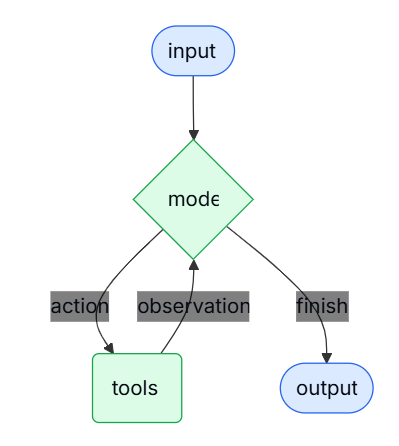

In [2]:
from langchain.agents import create_agent

def get_weather(city: str) -> str:
    """Get weather for a given city."""
    return f"It's always sunny in {city}!"

agent = create_agent(
    model="gpt-4o-mini",
    tools=[get_weather],
    system_prompt="You are a helpful assistant",
)

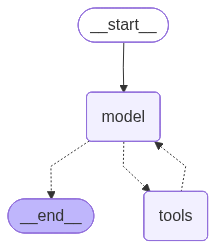

In [3]:
from IPython.display import Image, display

try:
    display(Image(agent.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [4]:
response = agent.invoke(
    {"messages": [{"role": "user", "content": "서울의 날씨가 어떤가요?"}]}
)

print(response)

{'messages': [HumanMessage(content='서울의 날씨가 어떤가요?', additional_kwargs={}, response_metadata={}, id='b9f1e9e2-7dfa-4093-b850-05cafdd73528'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 59, 'total_tokens': 73, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_93a2164d78', 'id': 'chatcmpl-DXIljCrmlH649Zlo3b1IanRmTuinW', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019db348-2410-7002-9562-063f961b75cb-0', tool_calls=[{'name': 'get_weather', 'args': {'city': '서울'}, 'id': 'call_3fqm61Jw1rFgNplAMHnsCdPv', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 59, 'output_tokens': 14, 'total_

In [5]:
for msg in response["messages"]:
    msg.pretty_print()

================================ Human Message =================================

서울의 날씨가 어떤가요?
================================== Ai Message ==================================
Tool Calls:
  get_weather (call_3fqm61Jw1rFgNplAMHnsCdPv)
 Call ID: call_3fqm61Jw1rFgNplAMHnsCdPv
  Args:
    city: 서울
================================= Tool Message =================================
Name: get_weather

It's always sunny in 서울!
================================== Ai Message ==================================

서울의 날씨는 맑습니다! 언제든지 외출하기 좋은 날입니다.


## 3. @tool 데코레이터로 커스텀 도구 만들기

`@tool` 데코레이터를 사용하면 함수를 LangChain 도구로 쉽게 변환할 수 있습니다.

1. **함수 이름**: 도구의 이름이 되므로 명확하고 설명적으로 작성
2. **Docstring**: LLM이 도구의 용도를 이해하는 데 사용되므로 필수
3. **타입 힌트**: 파라미터와 반환값에 타입을 명시하여 LLM이 올바르게 호출하도록 도움

In [ ]:
from langchain.tools import tool

@tool(parse_docstring=True) # 도구 설명을 docstring에서 자동으로 추출하도록 설정
def calculate_age(birth_year: int) -> str:
    """태어난 연도를 기준으로 나이를 계산합니다.

    Args:
        birth_year: 태어난 연도 (예: 1990)

    Returns:
        나이를 설명하는 텍스트(문자열)
    """
    from datetime import datetime
    current_year = datetime.now().year
    age = current_year - birth_year + 1
    return f"이 사람은 {age}세입니다. (현재 연도: {current_year})"

@tool(parse_docstring=True)
def multiply_numbers(a: float, b: float) -> str:
    """두 숫자를 곱합니다.

    Args:
        a: 첫 번째 숫자
        b: 두 번째 숫자

    Returns:
        a * b의 결과를 문자열로 반환
    """
    result = a * b
    return f"계산 결과: {a} × {b} = {result}"

print(f"\n도구 이름: {calculate_age.name}")
print(f"도구 설명: {calculate_age.description}")


도구 이름: calculate_age
도구 설명: 태어난 연도를 기준으로 나이를 계산합니다.

Args:
    birth_year: 태어난 연도 (예: 1990)

Returns:
    나이를 설명하는 텍스트(문자열)


> 구글 스타일 독스트링: https://google.github.io/styleguide/pyguide.html#383-functions-and-methods

## 4. 다중 도구를 가진 에이전트 만들기

여러 개의 도구를 에이전트에 제공하면, LLM이 상황에 맞는 도구를 선택하여 사용합니다.

In [7]:
multi_tool_agent = create_agent(
    model="gpt-4o-mini",
    tools=[calculate_age, multiply_numbers, get_weather],
    system_prompt="""당신은 여러 도구에 접근할 수 있는 유용한 어시스턴트입니다.
    사용자의 질문에 따라 적절한 도구를 사용하세요.
    항상 명확하고 친절한 응답을 제공하세요.""",
)

In [8]:
response = multi_tool_agent.invoke(
    {"messages": [{"role": "user", "content": "난 1990년에 태어났어. 내 나이가 몇 살이야?"}]}
)

for msg in response["messages"]:
    msg.pretty_print()

================================ Human Message =================================

난 1990년에 태어났어. 내 나이가 몇 살이야?
================================== Ai Message ==================================
Tool Calls:
  calculate_age (call_CeqiIor2jS1gsVeMTkumdeNm)
 Call ID: call_CeqiIor2jS1gsVeMTkumdeNm
  Args:
    birth_year: 1990
================================= Tool Message =================================
Name: calculate_age

이 사람은 37세입니다. (현재 연도: 2026)
================================== Ai Message ==================================

당신의 나이는 37세입니다.


In [9]:
question = "15 곱하기 20은 얼마야? 그리고 서울의 날씨는 어때?"

for chunk in multi_tool_agent.stream({"messages": [{"role": "user", "content": question}]}, stream_mode="updates"):
    for node, value in chunk.items():
        print(f"노드: {node}")
        if "messages" in value:
            for message in value["messages"]:
                message.pretty_print()

노드: model
================================== Ai Message ==================================
Tool Calls:
  multiply_numbers (call_pxbPgLbP5zGo78P1I4Y9nj5O)
 Call ID: call_pxbPgLbP5zGo78P1I4Y9nj5O
  Args:
    a: 15
    b: 20
  get_weather (call_LGJfpxzqp49LsSbsnvH9xsPX)
 Call ID: call_LGJfpxzqp49LsSbsnvH9xsPX
  Args:
    city: 서울
노드: tools
================================= Tool Message =================================
Name: multiply_numbers

계산 결과: 15.0 × 20.0 = 300.0
노드: tools
================================= Tool Message =================================
Name: get_weather

It's always sunny in 서울!
노드: model
================================== Ai Message ==================================

15 곱하기 20은 300입니다. 

서울의 날씨는 항상 맑습니다! 추가적인 정보가 필요하시면 말씀해 주세요.


---
### 참고 자료

- [LangChain Agents 공식 문서](https://docs.langchain.com/oss/python/langchain/agents)
- [LangChain Tools 공식 문서](https://docs.langchain.com/oss/python/langchain/tools)
- [LangChain Quickstart](https://docs.langchain.com/oss/python/langchain/quickstart)